In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from utils.plot_function import *
from utils.help_function import *
from scripts.experiments import DataHandler
#from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 

In [2]:
# load beh data
dh = DataHandler(cluster=False)
df_beh = dh.get_allsub_beh_data()
df_beh['bias_cc'] = df_beh['RespLoc'] - df_beh['AudLoc']

In [3]:
df_beh

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,Modality,mean,bias,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,bias_cc
0,-10.0,-10.0,1.0,1.0,-7.93,3.53,1.0,80.0,2,0.0,High,A,-8.312162,0.382162,0.382162,0.0,0.343813,-1.015708,2.07
1,-10.0,-10.0,1.0,1.0,-6.83,4.87,1.0,78.0,2,0.0,High,A,-8.312162,1.482162,1.482162,0.0,1.333430,-0.212409,3.17
2,-10.0,-10.0,1.0,1.0,-7.82,4.42,1.0,47.0,2,0.0,High,A,-8.312162,0.492162,0.492162,0.0,0.442775,-0.482174,2.18
3,-10.0,-10.0,1.0,1.0,-9.25,4.59,1.0,67.0,2,0.0,High,A,-8.312162,-0.937838,-0.937838,0.0,-0.843728,-0.380263,0.75
4,-10.0,-10.0,1.0,1.0,-11.43,4.54,2.0,29.0,2,0.0,High,A,-8.312162,-3.117838,-3.117838,0.0,-2.804969,-0.410236,-1.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19124,10.0,10.0,2.0,0.0,7.82,14.71,2.0,100.0,25,0.0,Low,V,7.770833,0.049167,0.049167,0.0,0.040545,1.138776,-2.18
19125,10.0,10.0,2.0,0.0,6.49,12.39,2.0,100.0,25,0.0,Low,V,7.770833,-1.280833,-1.280833,0.0,-1.056234,0.284694,-3.51
19126,10.0,10.0,2.0,0.0,6.94,7.97,1.0,78.0,25,0.0,Low,V,7.770833,-0.830833,-0.830833,0.0,-0.685143,-1.342480,-3.06
19127,10.0,10.0,2.0,0.0,10.23,8.48,1.0,100.0,25,0.0,Low,V,7.770833,2.459167,2.459167,0.0,2.027942,-1.154729,0.23


C:\Users\wenlou\AppData\Local\Temp\ipykernel_17756\3688787906.py:7: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17756\3688787906.py:20: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


Text(0.5, 0, 'Auditory location ($^\\circ$)')

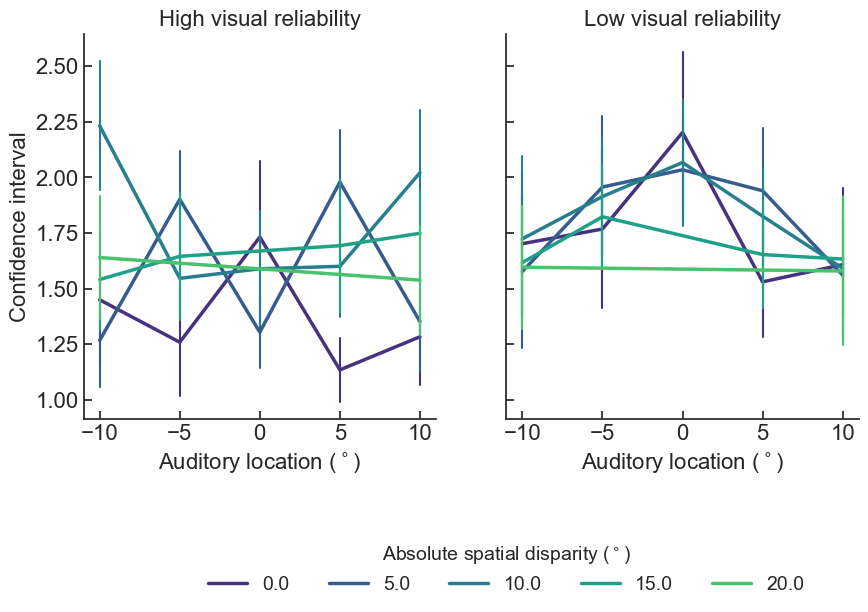

In [3]:
df = df_beh.loc[df_beh.Modality == 'A']

df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).CISize.std().reset_index()
palette = sns.color_palette("viridis", as_cmap=False)

fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'High'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[0],
    legend = None,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'Low'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[1],
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    #legend = None,
)
clean_axs(axs[0])
clean_axs(axs[1])

axs[1].legend(
    title='Absolute spatial disparity ($^\\circ$)',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0, -0.5),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


Text(0.5, 0, 'Auditory location ($^\\circ$)')

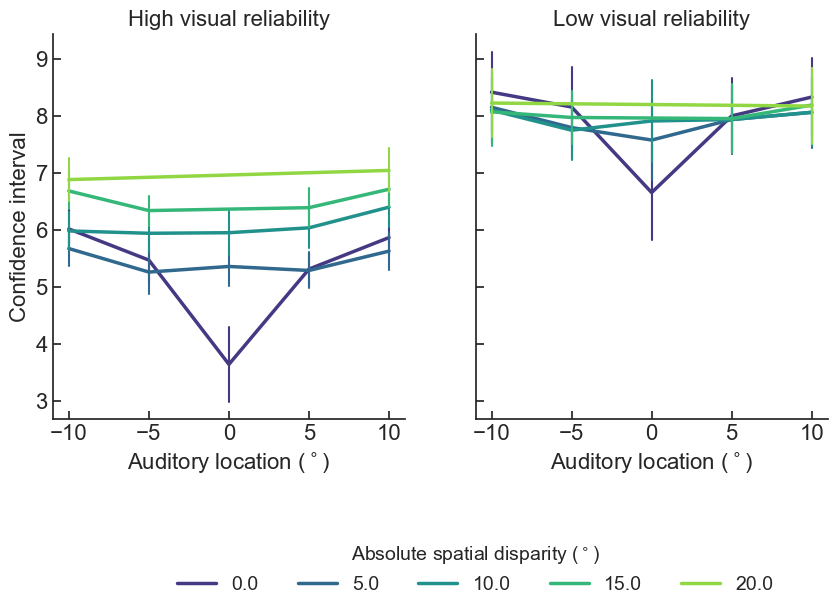

In [4]:
df = df_beh.loc[df_beh.Modality == 'A']

df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).CISize.mean().reset_index()

# fixed order of conditions
hue_order = sorted(df_plot['abs_delta_VA'].unique())

# explicit color mapping
colors = sns.color_palette("viridis", n_colors=len(hue_order))

palette = dict(zip(hue_order, colors))

fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'High'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    ax = axs[0],
    legend = None,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'Low'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    ax = axs[1],
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    #legend = None,
)
clean_axs(axs[0])
clean_axs(axs[1])

axs[1].legend(
    title='Absolute spatial disparity ($^\\circ$)',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0, -0.5),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


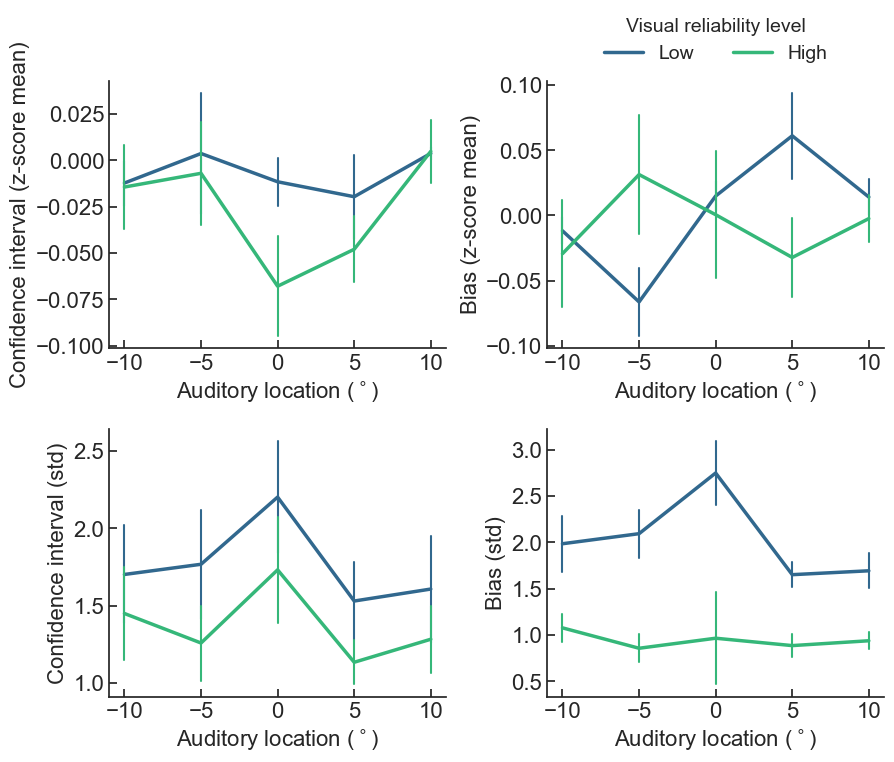

In [7]:
from matplotlib.gridspec import GridSpec

palette = sns.color_palette("viridis", as_cmap=False, n_colors=2)
hue_order = ['Low', 'High']

df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.AudLoc== df_beh.VisLoc)] # congruent auditory-visual trials
df_plot = (
    df.groupby(['sub_id', 'VisRelLabel', 'AudLoc'])
      .agg(
          CI_mean=('CISize_zscore', 'mean'),
          CI_mean_ori = ('CISize', 'mean'),
          CI_sd=('CISize', 'std'),
          bias_mean=('bias_zscore', 'mean'),
          bias_mean_ori = ('bias', 'mean'),
          bias_sd=('bias', 'std'),
          #resp_mean=('RespLoc', 'mean'),
      )
      .reset_index()
)

# coefficient of variation
df_plot['CI_cv'] = df_plot['CI_sd'] / df_plot['CI_mean_ori']
df_plot['bias_cv'] = df_plot['bias_sd'] / df_plot['bias_mean_ori']

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='CI_mean',
    hue = 'VisRelLabel',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax1,
    legend = None
)

ax2 = fig.add_subplot(gs[0, 1])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='bias_mean',
    hue = 'VisRelLabel',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax2,
    #legend = None
)

ax3 = fig.add_subplot(gs[1, 0])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='CI_sd',
    hue = 'VisRelLabel',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax3,
    legend = None
)



ax4 = fig.add_subplot(gs[1, 1])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='bias_sd',
    hue = 'VisRelLabel',
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax4,
    legend = None
)

#sns.lineplot(x=np.linspace(-10, 10, 100), y=np.linspace(-10, 10, 100), linestyle="--", color = 'red', ax = axs[1])

clean_axs(ax1)
clean_axs(ax2)
clean_axs(ax3)
clean_axs(ax4)

ax2.legend(
    title='Visual reliability level',
    frameon=False,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, 1),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
#axs.set_title('Uni-sensory auditory report', fontsize=fontsize)
#axs[1].set_ylim(-0.5,0.5)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)

ax1.set_ylabel('Confidence interval (z-score mean)', fontsize=fontsize)
ax3.set_ylabel('Confidence interval (std)', fontsize=fontsize)
ax2.set_ylabel('Bias (z-score mean)', fontsize=fontsize)
ax4.set_ylabel('Bias (std)', fontsize=fontsize)

#adjust space between subplots
plt.subplots_adjust(wspace=0.3, hspace=0.3)

In [10]:
df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.AudLoc== df_beh.VisLoc)] # congruent auditory-visual trials
df_plot = (
    df.groupby(['sub_id', 'VisRelLabel', 'AudLoc'])
      .agg(
          CI_mean=('CISize', 'mean'),
          CI_sd=('CISize', 'std'),
          bias_mean=('bias', 'mean'),
          bias_sd=('bias', 'std')
      )
      .reset_index()
)
df_plot

,sub_id,VisRelLabel,AudLoc,CI_mean,CI_sd,bias_mean,bias_sd
0,2,High,-10.0,5.224324,1.668122,-3.600723e-16,1.111541
1,2,High,-5.0,4.509722,1.147383,8.016517e-02,0.809399
2,2,High,0.0,3.015143,1.918031,-2.033822e-01,0.539386
3,2,High,5.0,4.978108,0.984995,-2.017905e-16,1.105083
4,2,High,10.0,5.127568,1.425662,2.760555e-16,0.966139
...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.110256,2.239088,8.782149e-16,0.963280
76,25,Low,-5.0,9.598333,1.994457,-5.561988e-01,1.308240
77,25,Low,0.0,5.042821,4.259963,0.000000e+00,2.140606
78,25,Low,5.0,10.143421,1.534540,1.463968e-01,1.067052


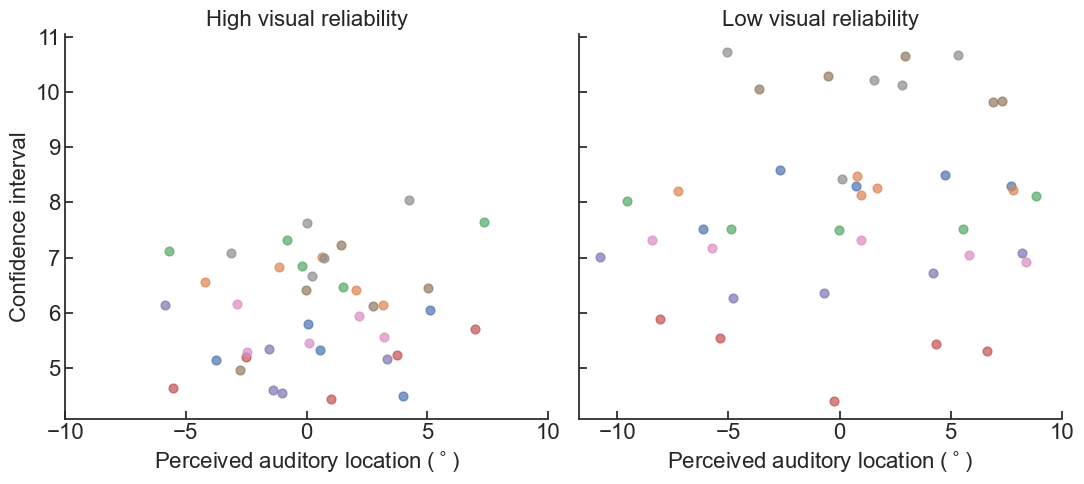

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# --- keep subject-level averaging ---
df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.abs_delta_VA==10)]
df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).agg({'CISize': 'mean', 'RespLoc': 'mean'}).reset_index()

# df_plot = df.groupby(
#     ['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']
# ).CISize.mean().reset_index()
# --- consistent colormap ---
cmap = sns.color_palette("viridis", as_cmap=True)
norm = plt.Normalize(df_plot['abs_delta_VA'].min(), df_plot['abs_delta_VA'].max())

fig, axs = plt.subplots(figsize=(11, 5), ncols=2, sharey=True)

for ax, label in zip(axs, ['High', 'Low']):
    subset = df_plot[df_plot.VisRelLabel == label]

    for sub_id, sub_data in subset.groupby('sub_id'):
        ax.scatter(
            sub_data['RespLoc'],
            sub_data['CISize'],
            label=sub_id,   # optional legend
            alpha=0.7,
            s=40
        )

    clean_axs(ax)
    ax.set_xticks([ -10, -5, 0, 5, 10])
    ax.set_title(f'{label} visual reliability', fontsize=fontsize)

# labels
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
for ax in axs:
    ax.set_xlabel('Perceived auditory location ($^\\circ$)', fontsize=fontsize)

# --- colorbar instead of cluttered legend ---
#cbar = fig.colorbar(sc, ax=axs, orientation='horizontal', fraction=0.08, pad=0.2)
#cbar.set_label('Absolute spatial disparity ($^\\circ$)', fontsize=fontsize)

plt.tight_layout()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_22908\4035148700.py:7: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_22908\4035148700.py:20: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(


Text(0.5, 0, 'Auditory location ($^\\circ$)')

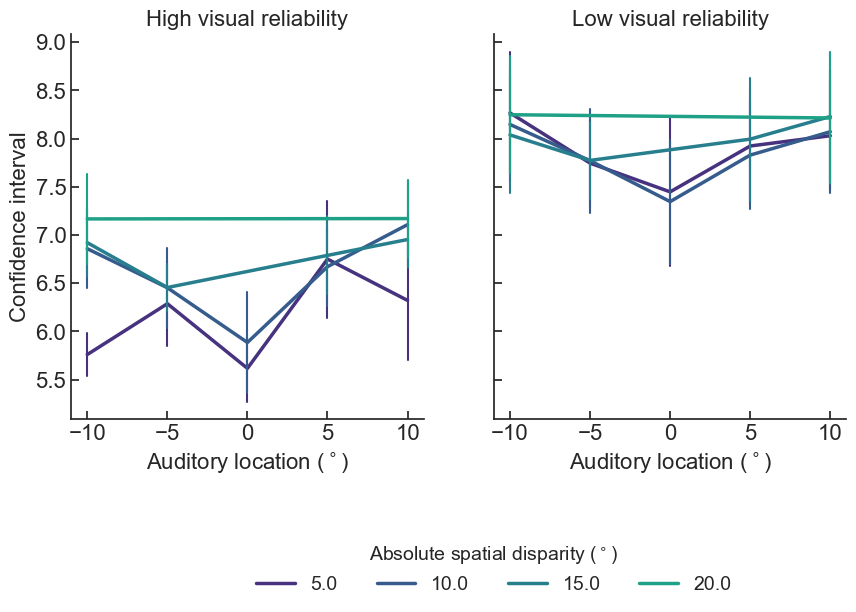

In [9]:
df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.AudLoc!= df_beh.VisLoc)&(df_beh.Sources == 2)]

df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).CISize.mean().reset_index()
palette = sns.color_palette("viridis", as_cmap=False)

fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'High'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[0],
    legend = None,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'Low'],
    x='AudLoc',
    y='CISize',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[1],
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    #legend = None,
)
clean_axs(axs[0])
clean_axs(axs[1])

axs[1].legend(
    title='Absolute spatial disparity ($^\\circ$)',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0, -0.5),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


C:\Users\wenlou\AppData\Local\Temp\ipykernel_22908\1602988779.py:7: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_22908\1602988779.py:20: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.lineplot(


Text(0.5, 0, 'Auditory location ($^\\circ$)')

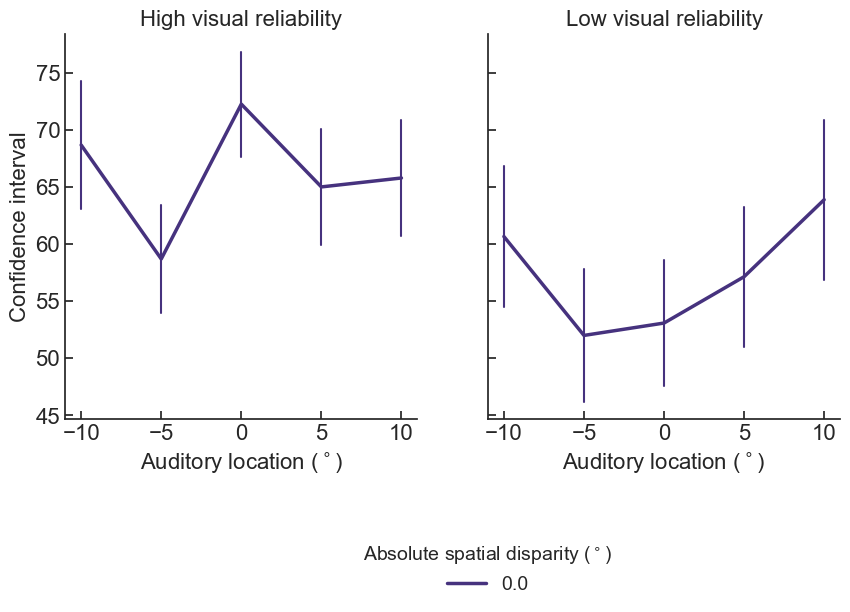

In [14]:
df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.AudLoc== df_beh.VisLoc)]

df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc']).ConfLevel.mean().reset_index()
palette = sns.color_palette("viridis", as_cmap=False)

fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'High'],
    x='AudLoc',
    y='ConfLevel',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[0],
    legend = None,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'Low'],
    x='AudLoc',
    y='ConfLevel',
    hue='abs_delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[1],
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    #legend = None,
)
clean_axs(axs[0])
clean_axs(axs[1])

axs[1].legend(
    title='Absolute spatial disparity ($^\\circ$)',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0, -0.5),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


C:\Users\wenlou\AppData\Local\Temp\ipykernel_14448\2945372647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['source_label'] = df['Sources'].map({1:'Common', 2:'Separate'})


Text(0.5, 0, 'Visual reliability')

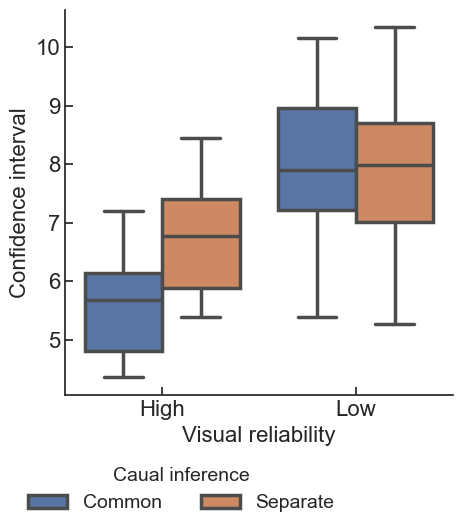

In [102]:
df = df_beh.loc[(df_beh.Modality == 'A')]
df['source_label'] = df['Sources'].map({1:'Common', 2:'Separate'})
df_plot = df.groupby(['sub_id', 'VisRelLabel', 'source_label', 'delta_VA']).CISize.mean().reset_index()
df_plot = df_plot.groupby(['sub_id', 'VisRelLabel', 'source_label']).CISize.mean().reset_index()
#palette = sns.color_palette("viridis", as_cmap=False)
#&(df_beh.delta_VA != 0)
fig, axs = plt.subplots(figsize = (5, 5))
sns.boxplot(
    data=df_plot,
    x='VisRelLabel',
    y='CISize',
    hue='source_label',
    ##palette=palette,
    linewidth=2.5,
    #legend = None,
    # estimator = 'mean',
    # errorbar='se',
    # err_style='bars',
)

clean_axs(axs)

axs.legend(
    title='Caual inference',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.3, -0.35),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)

axs.set_ylabel('Confidence interval', fontsize=fontsize)
axs.set_xlabel('Visual reliability', fontsize=fontsize)
# axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


In [103]:
from scipy.stats import wilcoxon

wide = (
    df_plot[df_plot.VisRelLabel == 'High']
    .pivot(index='sub_id', columns='source_label', values='CISize')
    .dropna()
)

stat, p = wilcoxon(wide['Common'], wide['Separate'], alternative='less')
print(stat, p)


0.0 0.00390625


In [104]:
wide = (
    df_plot[df_plot.VisRelLabel == 'Low']
    .pivot(index='sub_id', columns='source_label', values='CISize')
    .dropna()
)

stat, p = wilcoxon(wide['Common'], wide['Separate'], alternative = 'less')
print(stat, p)


16.0 0.421875


C:\Users\wenlou\AppData\Local\Temp\ipykernel_14448\2797405800.py:7: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(
c:\Users\wenlou\.conda\envs\cluster\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\wenlou\.conda\envs\cluster\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_14448\2797405800.py:20: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(
c:\Users\wenlou\.conda\envs\cluster\Lib\site-packages\matplotlib\cbook.py:1

Text(0.5, 0, 'Auditory location ($^\\circ$)')

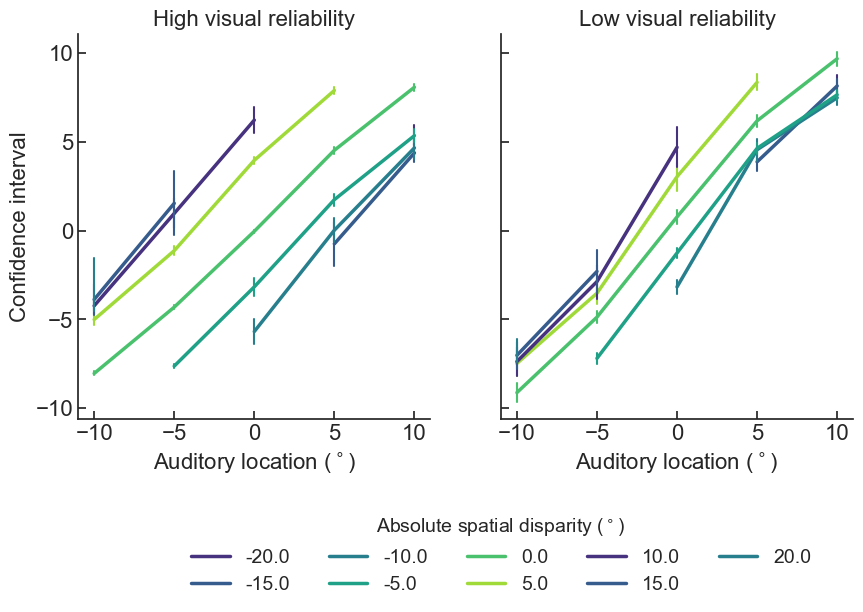

In [6]:
df = df_beh.loc[df_beh.Modality == 'A']

df_plot = df.groupby(['sub_id', 'VisRelLabel', 'delta_VA', 'AudLoc']).RespLoc.mean().reset_index()
palette = sns.color_palette("viridis", as_cmap=False)

fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'High'],
    x='AudLoc',
    y='RespLoc',
    hue='delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[0],
    legend = None,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
)
sns.lineplot(
    data=df_plot[df_plot.VisRelLabel == 'Low'],
    x='AudLoc',
    y='RespLoc',
    hue='delta_VA',
    palette=palette,
    linewidth=2.5,
    ax = axs[1],
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    #legend = None,
)
clean_axs(axs[0])
clean_axs(axs[1])

axs[1].legend(
    title='Absolute spatial disparity ($^\\circ$)',
    frameon=False,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0, -0.5),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


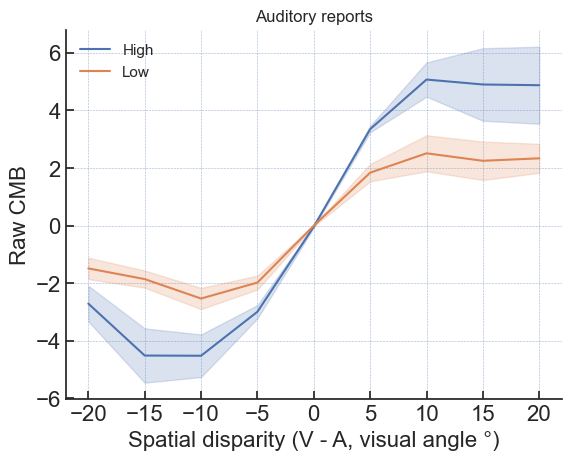

In [4]:
plot_VE(df=df_beh,  raw_CMB=1, trial_type='A',plot_label='', save_fig = 0)

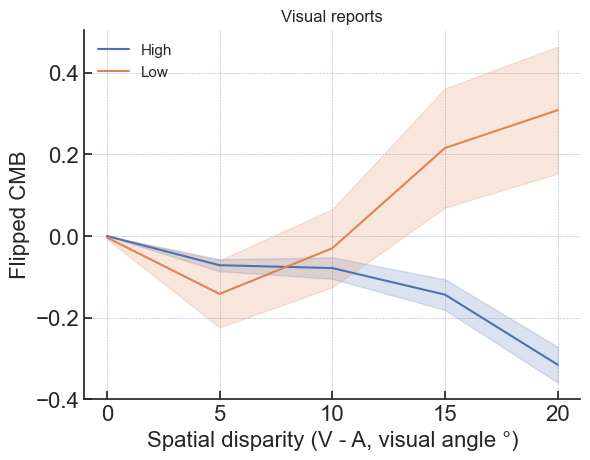

In [6]:
plot_VE(df=df_beh,  raw_CMB=0, trial_type='V',plot_label='', save_fig = 0)

## Causal metamer

Text(0.5, 1.0, 'All trials')

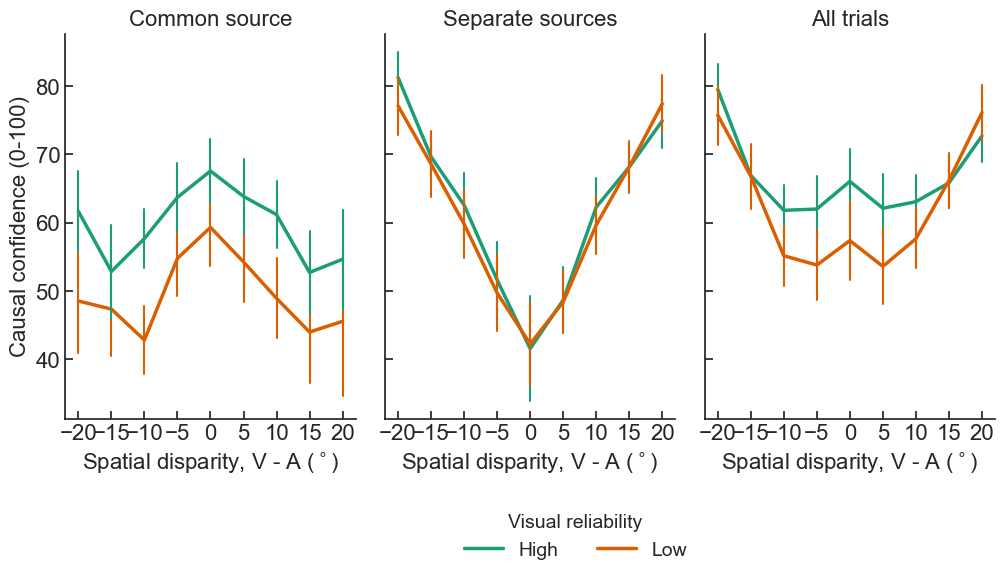

In [9]:
fig, axs = plt.subplots(figsize=(12, 5), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1})
plot_group_pattern(df=df_beh, yvar='ConfLevel', trial_type='A', com_label='Common', ax=axs[0])
plot_group_pattern(df=df_beh, yvar='ConfLevel', trial_type='A', com_label='Separate', ax=axs[1])
plot_group_pattern(df=df_beh, yvar='ConfLevel', trial_type='A', com_label='Total', ax=axs[2], leg='auto')
axs[0].set_title('Common source', fontsize=fontsize)
axs[1].set_title('Separate sources', fontsize=fontsize)
axs[2].set_title('All trials', fontsize=fontsize)

Text(0.5, 1.0, 'All trials')

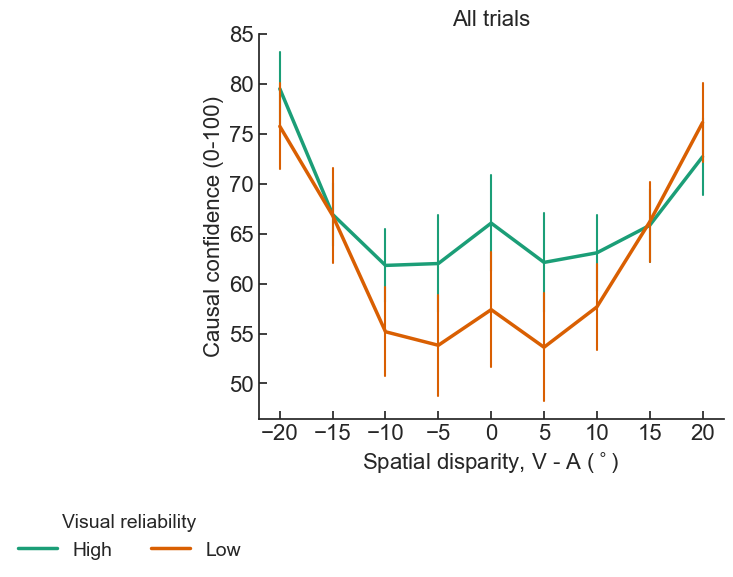

In [7]:
fig, axs = plt.subplots(figsize=(6, 5))
plot_group_pattern(df=df_beh, yvar='ConfLevel', trial_type='A', com_label='Total', ax=axs, leg='auto')
#plot_group_pattern(df=df_beh, yvar='ConfLevel', trial_type='A', com_label='Total', ax=axs[2], leg='auto')
axs.set_title('All trials', fontsize=fontsize)

## UNI - SENSORY

In [3]:
raw_data_path = 'P:/3026008.02/rawData/'
data_path = 'P:/3026008.02/AllData/'
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20, 25]

#data preparation
df_uni_A = pd.DataFrame()
df_uni_V = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    # filter out the unisensory data
    sub_uniA_data = subA_data[subA_data['Vis Loc'].isna()].reset_index(drop=True)
    sub_uniA_data['sub_id'] = sub_id
    sub_uniA_data['Modality'] = 'A'
    sub_uniA_data['stim_loc'] = sub_uniA_data['Aud Loc']
    sub_uniA_data['Vis Rel'] = 0 # reassign the visual reliability to 0 for uni-sensory auditory blocks
    sub_uniV_data = subV_data[subV_data['Aud Loc'].isna()].reset_index(drop=True)
    sub_uniV_data['sub_id'] = sub_id
    sub_uniV_data['Modality'] = 'V'
    sub_uniV_data['stim_loc'] = sub_uniV_data['Vis Loc']
     # concatenate the data
    df_uni_V = pd.concat([df_uni_V, sub_uniV_data], ignore_index=True)
    df_uni_A = pd.concat([df_uni_A, sub_uniA_data], ignore_index=True)

In [4]:
df_uni_A = df_uni_A.rename(columns={'CI Size':'CISize', 'Aud Loc':'AudLoc', 'Vis Rel':'VisRel', 'Resp Loc':'RespLoc'})
df_uni_A.head()

,Block Nr,Trial Nr,AudLoc,Vis Loc,VisRel,RespLoc,CISize,Sources,Conf Level,sub_id,Modality,stim_loc
0,1,1,-5,NaN,0,-3.59,6.49,NaN,NaN,2,A,-5
1,1,13,0,NaN,0,-4.15,5.15,NaN,NaN,2,A,0
2,1,25,10,NaN,0,8.59,5.71,NaN,NaN,2,A,10
3,1,27,5,NaN,0,5.60,5.34,NaN,NaN,2,A,5
4,1,28,-10,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10


In [5]:
df_stat = df_uni_A.groupby(['sub_id', 'VisRel', 'AudLoc'])['RespLoc'].agg(['mean', 'std']).reset_index()
df_aud = df_uni_A.merge(df_stat.loc[:, ['sub_id', 'VisRel', 'AudLoc', 'mean']], how='left', on=['sub_id', 'VisRel', 'AudLoc'])
df_aud['bias'] = df_aud['RespLoc'] - df_aud['mean']
df_aud['bias_cc'] = df_aud['RespLoc'] - df_aud['AudLoc']
df_aud.head()

,Block Nr,Trial Nr,AudLoc,Vis Loc,VisRel,RespLoc,CISize,Sources,Conf Level,sub_id,Modality,stim_loc,mean,bias,bias_cc
0,1,1,-5,NaN,0,-3.59,6.49,NaN,NaN,2,A,-5,-3.978108,0.388108,1.41
1,1,13,0,NaN,0,-4.15,5.15,NaN,NaN,2,A,0,0.212329,-4.362329,-4.15
2,1,25,10,NaN,0,8.59,5.71,NaN,NaN,2,A,10,8.218784,0.371216,-1.41
3,1,27,5,NaN,0,5.60,5.34,NaN,NaN,2,A,5,4.385270,1.214730,0.60
4,1,28,-10,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10,-7.594730,2.664730,5.07


In [6]:
df_plot = pd.concat([df_aud.loc[: ,['sub_id', 'AudLoc', 'VisRel', 'CISize', 'bias', 'bias_cc']],df_beh.loc[(df_beh.Modality == 'A') &(df_beh.abs_delta_VA==0), ['sub_id','AudLoc', 'VisRel', 'CISize', 'bias','bias_cc']]], ignore_index=True)
df_plot

,sub_id,AudLoc,VisRel,CISize,bias,bias_cc
0,2,-5.0,0.0,6.49,0.388108,1.41
1,2,0.0,0.0,5.15,-4.362329,-4.15
2,2,10.0,0.0,5.71,0.371216,-1.41
3,2,5.0,0.0,5.34,1.214730,0.60
4,2,-10.0,0.0,5.80,2.664730,5.07
...,...,...,...,...,...,...
5778,25,10.0,2.0,9.22,0.808462,-1.63
5779,25,10.0,2.0,8.40,-0.511538,-2.95
5780,25,10.0,2.0,12.33,0.038462,-2.40
5781,25,10.0,2.0,8.47,2.778462,0.34


In [7]:
df_plot['vislabel']= df_plot.VisRel.map({0:'Uni-sensory', 1:'Bi-sensory congruent high V reliability', 2:'Bi-sensory congruent low V reliability'})

In [24]:
df_plot

,sub_id,AudLoc,VisRel,CISize,bias,vislabel
0,2,-5.0,0.0,6.49,0.388108,Uni-sensory
1,2,0.0,0.0,5.15,-4.362329,Uni-sensory
2,2,10.0,0.0,5.71,0.371216,Uni-sensory
3,2,5.0,0.0,5.34,1.214730,Uni-sensory
4,2,-10.0,0.0,5.80,2.664730,Uni-sensory
...,...,...,...,...,...,...
5778,25,10.0,2.0,9.22,0.808462,Bi-sensory congruent low V reliability
5779,25,10.0,2.0,8.40,-0.511538,Bi-sensory congruent low V reliability
5780,25,10.0,2.0,12.33,0.038462,Bi-sensory congruent low V reliability
5781,25,10.0,2.0,8.47,2.778462,Bi-sensory congruent low V reliability


Text(0.5, 0, 'Auditory location ($^\\circ$)')

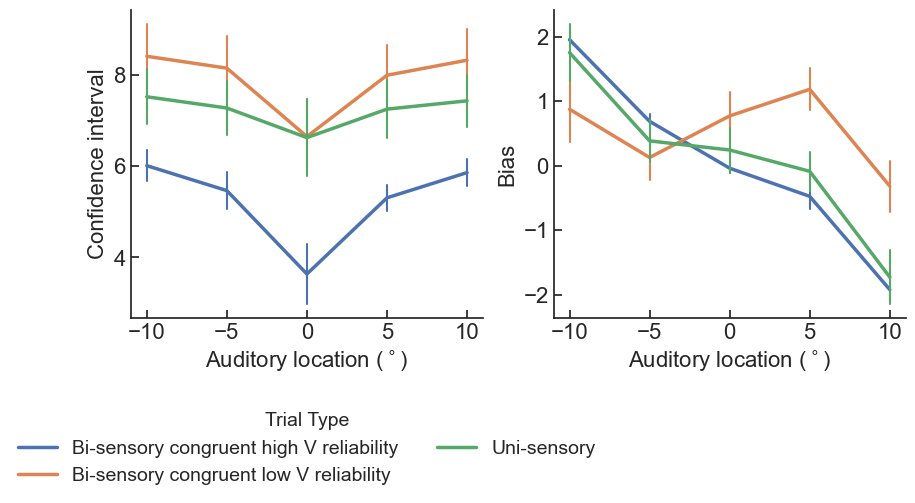

In [14]:
from matplotlib.gridspec import GridSpec


palette = sns.color_palette("viridis", as_cmap=False)

df_plot = df_plot.groupby(['sub_id', 'vislabel', 'AudLoc'])[['CISize','bias', 'bias_cc']].mean().reset_index()

fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[:, 0])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='CISize',
    hue = 'vislabel',
    #palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax1
)
ax2 = fig.add_subplot(gs[0, 1])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='bias_cc',
    hue = 'vislabel',
    #palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax2,
    legend = None
)

#sns.lineplot(x=np.linspace(-10, 10, 100), y=np.linspace(-10, 10, 100), linestyle="--", color = 'red', ax = axs[1])

clean_axs(ax1)
clean_axs(ax2)

ax1.legend(
    title='Trial Type',
    frameon=False,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.6),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
#axs.set_title('Uni-sensory auditory report', fontsize=fontsize)
#axs[1].set_ylim(-0.5,0.5)
ax1.set_ylabel('Confidence interval', fontsize=fontsize)
ax1.set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
ax2.set_ylabel('Bias', fontsize=fontsize)
ax2.set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)

In [29]:
df_plot

,sub_id,vislabel,AudLoc,CISize,bias
0,2,Bi-sensory congruent high V reliability,-10.0,5.224324,-3.600723e-16
1,2,Bi-sensory congruent high V reliability,-5.0,4.509722,8.016517e-02
2,2,Bi-sensory congruent high V reliability,0.0,3.015143,-2.033822e-01
3,2,Bi-sensory congruent high V reliability,5.0,4.978108,-2.017905e-16
4,2,Bi-sensory congruent high V reliability,10.0,5.127568,2.760555e-16
...,...,...,...,...,...
115,25,Uni-sensory,-10.0,9.966800,-1.302662e-16
116,25,Uni-sensory,-5.0,9.059452,-2.433366e-16
117,25,Uni-sensory,0.0,7.911867,-7.105427e-17
118,25,Uni-sensory,5.0,9.697838,2.160434e-16


In [19]:
from scipy import stats
t_stat, p_value = stats.ttest_1samp(df_plot.bias[(df_plot.vislabel=='Bi-sensory congruent low V reliability')&(df_plot.AudLoc==-5)], popmean=0, alternative="less")

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.362774143792926
p-value: 0.025068130454723125
